In [18]:
import sys
sys.path.append("../")

from src import regmod
from src import solver

from src.utils import *

import nibabel as nib

In [19]:
save_plots = False

In [20]:
img = nib.load('/Users/mikichan/Desktop/mywork/data_resources/atlas_data/f-tract_v2112/lausanne2008_33-meta/region_masks.nii')
masks_volume = img.get_fdata()
regions_centroid = np.array([np.array(np.where(masks_volume == r)).T.mean(axis=0) for r in range(1, int(masks_volume.max()) + 1)])

In [21]:
def relative_error(y_true, y_pred):
    div = np.abs(y_true)
    div[div == 0] = 1  # to avoid division by zero
    distrib = np.abs(y_true - y_pred) / div
    return distrib.mean(), distrib.std()

## Description

Testing sparsifying scheme and observe the regression of delays' results. 

Performed on :
- f-tract

## F-tract Example

In [22]:
# This is only for Penghui, remove this later
# adj = load(op.join(path_to_data, filename))
# streamline_view_2008 = load('/Users/mikichan/Desktop/mywork/data_resources/atlas_data/fiber_atlas_2008/streamline_view.pkl')
# save('./dmatrix_streamlines.pkl', {'direction_probability': adj[:83, :83], 'nb_streamlines': streamline_view_2008[:83, :83]})

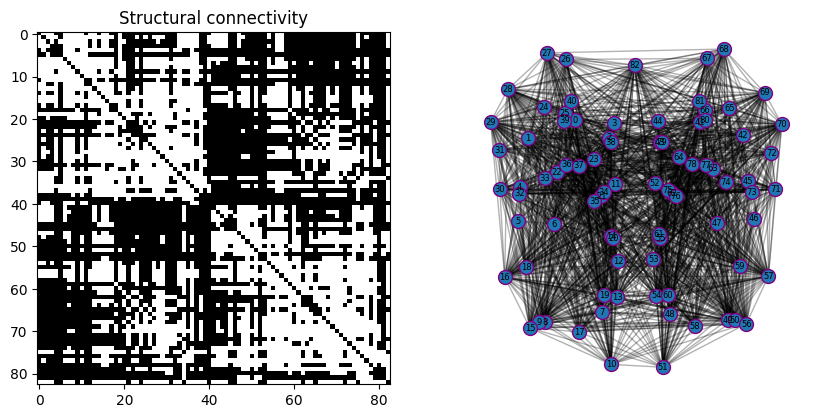

In [23]:
path_to_data = "../resources"

# Could be 50, 100, 200, 400
delay_max = 400
path_to_ftract = f"/Users/mikichan/Desktop/mywork/data_resources/atlas_data/f-tract_v2112/F-TRACT-090624/{delay_max}"

filename = "bundle_probability_atlas.pkl"

adj = load(op.join(path_to_data, filename))

adj = adj[:83, :83]
adj -= np.diag(np.diag(adj))
N = adj.shape[0]

bundle_prob_thresh = 0.9

adj = (adj > bundle_prob_thresh).astype(int)

bundle_prob = load(op.join(path_to_data, "bundle_probability_atlas.pkl"))
bundle_prob = bundle_prob[:83, :83]
bundle_prob -= np.diag(np.diag(bundle_prob))
ftract_prob = load(op.join(path_to_data, "adj_probability_ftract.pkl"))
ftract_prob = ftract_prob[:83, :83]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axes[0].imshow(adj, cmap='gray')
axes[0].set_title('Structural connectivity')
toy_graph = nx.Graph(adj)
pos = {i: regions_centroid[i][:2] for i in range(len(regions_centroid))}
# draw nodes, edges with transparency, and labels
nx.draw_networkx_nodes(toy_graph, pos=pos, ax=axes[1], node_size=100, edgecolors='purple')
nx.draw_networkx_edges(toy_graph, pos=pos, ax=axes[1], alpha=0.3, edge_color='black')
nx.draw_networkx_labels(toy_graph, pos=pos, ax=axes[1], font_size=6)
axes[1].set_axis_off()

In [24]:
# Pre-Compute design matrices
max_path_depth = 1

if op.exists(op.join(path_to_data, f"design_matrices_maxdepth{max_path_depth}.pkl")):
    design_matrices = load(op.join(path_to_data, f"design_matrices_maxdepth{max_path_depth}.pkl"))
else:
    design_matrices = regmod.get_shortest_matrices(adj, max_path_depth, progress=True)
    save(op.join(path_to_data, f"design_matrices_maxdepth{max_path_depth}.pkl"), design_matrices)

## Synthetic example - fill in

In [25]:
# Assigining the ground truth x vector
reduced_adj = deepcopy(adj)

a = 0.5
# Computes the alpha vector as alpha_n = a^n
alpha = solver.torch.tensor([a**(i+1) for i in range(max_path_depth)])

# Build design matrix
design_shortest = regmod.build_design_shortest(reduced_adj, n_subopt=max_path_depth - 1, alpha=a)
design_model = solver.torch.tensor(design_shortest)
x_ground = remove_diagonal_entries(reduced_adj).flatten().astype(float)

  0%|          | 0/6806 [00:00<?, ?it/s]

In [26]:
# Now removing some observations i.e from y_pred/y_ground
y_pred = solver.forward(design_model, solver.torch.tensor(x_ground))

# Randomly remove 20% of the observations
np.random.seed(99)
y_non_complete = deepcopy(y_pred)
n_remove = int(0.2 * len(y_pred))
remove_indices = np.random.choice(len(y_pred), size=n_remove, replace=False)
y_non_complete[remove_indices] = 0.0  # Set removed observations to zero

y_ground = solver.torch.tensor(deepcopy(y_non_complete))

/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_22049/2643642832.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_ground = solver.torch.tensor(deepcopy(y_non_complete))


In [27]:
init_pseudo = False
if init_pseudo:
    x_pseudo = solver.pseudo_inverse(y_pred.numpy(), a_design=design_model.numpy())
    x_init = solver.torch.tensor(x_pseudo).requires_grad_(True)
else:
    np.random.seed(99)
    x_init = solver.torch.tensor(np.random.rand(len(x_ground))).requires_grad_(True)

In [28]:
# Checking for zero entries in the y vector (conduction delays)
# As we cannot fit those values, we remove them from the regression
# (equivalent to removing the corresponding rows in the design matrix) 
non_zero_mask = y_ground > 0

y_masked = y_ground[non_zero_mask]
design_model_masked = design_model[non_zero_mask]

In [29]:
x = deepcopy(x_init)
x_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver(x, y_masked, design_model_masked,
                                            n_iter=2000, verbose=False, 
                                            early_stop=1e-10, step_size=5e-2,
                                            l2_penalty=5e-1, return_logs=True)

#### Checking up on estimated effective delays

(<Figure size 1000x500 with 4 Axes>,
 <Axes: title={'center': 'Estimated Effective delays w/ loss=0.2828'}>)

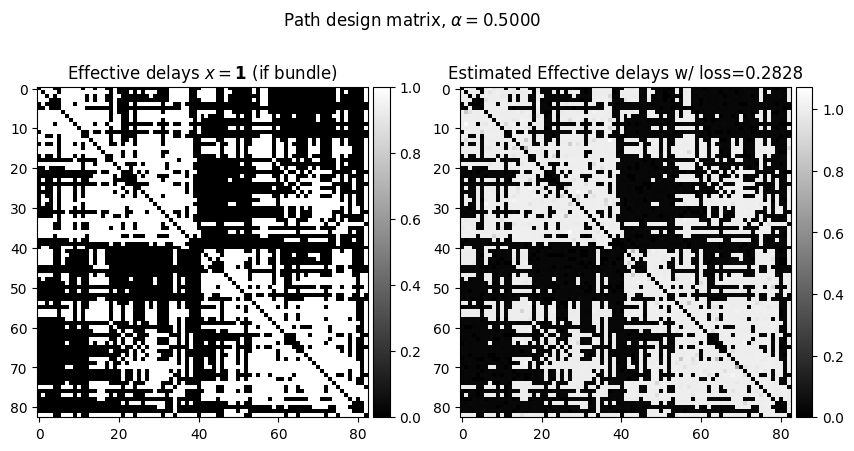

In [32]:
x_ground_mat = add_diagonal_entries(x_ground.reshape(reduced_adj.shape[0], reduced_adj.shape[1]-1))
x_pred_mat = add_diagonal_entries(x_opt.reshape(reduced_adj.shape[0], reduced_adj.shape[1]-1))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
fig.suptitle(rf"Path design matrix, $\alpha=$"+" ".join([f"{a:1.4f}" for a in list(alpha)]))
axes[0].imshow(x_ground_mat, cmap='gray')
axes[0].set_title("Effective delays $x=\mathbf{1}$ (if bundle)")
add_cbar(fig, axes[0])
# utils.annotate_heatmap(fig, axes[0], x_ground_mat, adapt_color=0.6)

axes[1].imshow(x_pred_mat, cmap='gray')#, vmax=y_pred_mat.max())
axes[1].set_title(f"Estimated Effective delays w/ loss={np.round(loss,4)}")
add_cbar(fig, axes[1])
# annotate_heatmap(fig, axes[1], np.round(x_pred_mat,4), adapt_color=0.6)

/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_22049/1442996538.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(samples, labels=['w/ conduction', 'w/o conduction'], showmeans=True)


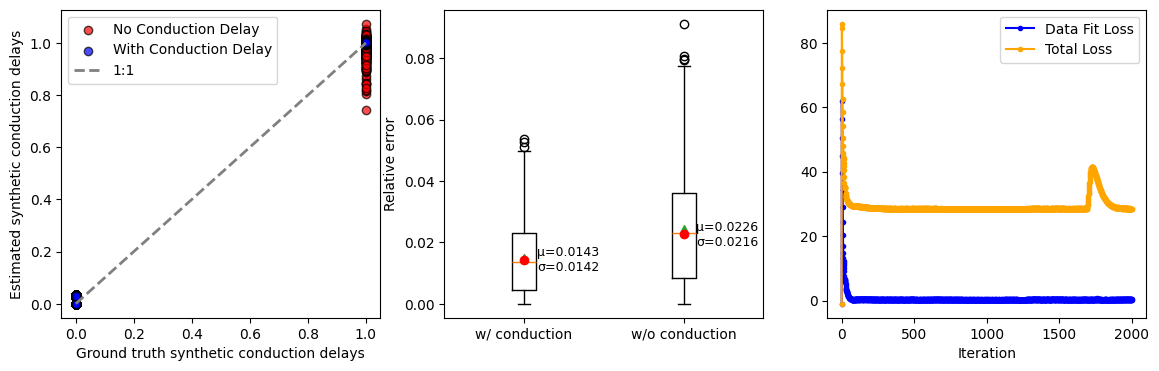

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(14,4))

ax[0].scatter(x_ground[~non_zero_mask], x_opt[~non_zero_mask], edgecolor='k', alpha=0.7, color='red', label='No Conduction Delay')
ax[0].scatter(x_ground[non_zero_mask], x_opt[non_zero_mask], edgecolor='k', alpha=0.7, color='blue', label='With Conduction Delay')
ax[0].plot(np.linspace(0,x_ground.max()), np.linspace(0,x_ground.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth synthetic conduction delays')
ax[0].set_ylabel('Estimated synthetic conduction delays')
ax[0].legend()

ax[2].plot(df_loss, label='Data Fit Loss', color='blue', marker='o', markersize=3)
ax[2].plot(loss_logs, label='Total Loss', color='orange', marker='o', markersize=3)
ax[2].set_xlabel('Iteration')
ax[2].legend()

deviation_percent_masked = relative_error(x_ground[non_zero_mask], x_opt[non_zero_mask])
deviation_percent = relative_error(x_ground[~non_zero_mask], x_opt[~non_zero_mask])

# create synthetic samples from the provided mean/std and plot a boxplot
np.random.seed(0)

means = [float(deviation_percent_masked[0]), float(deviation_percent[0])]
stds  = [float(deviation_percent_masked[1]), float(deviation_percent[1])]

n_samples = 1000
samples = [np.clip(np.random.normal(loc=m, scale=s, size=n_samples), a_min=0, a_max=None)
           for m, s in zip(means, stds)]

ax[1].boxplot(samples, labels=['w/ conduction', 'w/o conduction'], showmeans=True)
for i, (m, s) in enumerate(zip(means, stds), start=1):
    ax[1].scatter(i, m, color='red', zorder=3)
    ax[1].text(i + 0.08, m, f"μ={m:.4f}\nσ={s:.4f}", va='center', fontsize=9)

ax[1].set_ylabel('Relative error')
plt.show()

#### Checking up on estimated conductance delays

In [86]:
y_est_opt = solver.forward(design_model, solver.torch.tensor(x_opt)).numpy()

y_est_mat = add_diagonal_entries(y_est_opt.reshape(reduced_adj.shape[0], reduced_adj.shape[1]-1))
y_ground_mat = add_diagonal_entries(y_ground.numpy().reshape(reduced_adj.shape[0], reduced_adj.shape[1]-1))

Text(0.5, 1.0, 'Ground truth conduction delays matrix')

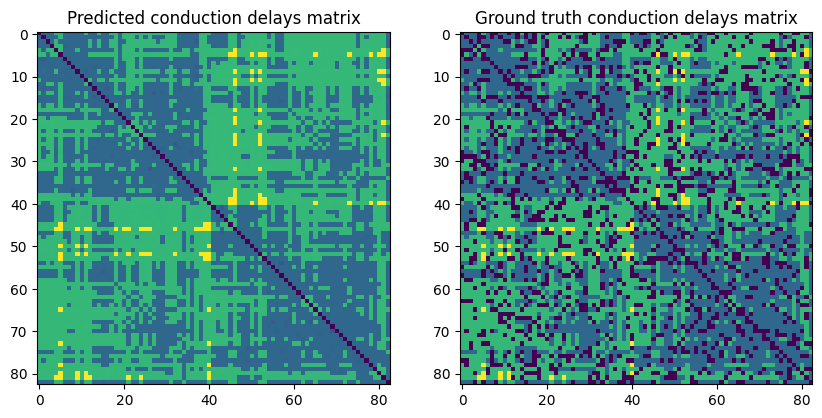

In [87]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(y_est_mat, vmin=0, vmax=y_ground_mat.max())
ax[0].set_title('Predicted conduction delays matrix')
ax[1].imshow(y_ground_mat, vmin=0, vmax=y_ground_mat.max())
ax[1].set_title('Ground truth conduction delays matrix')

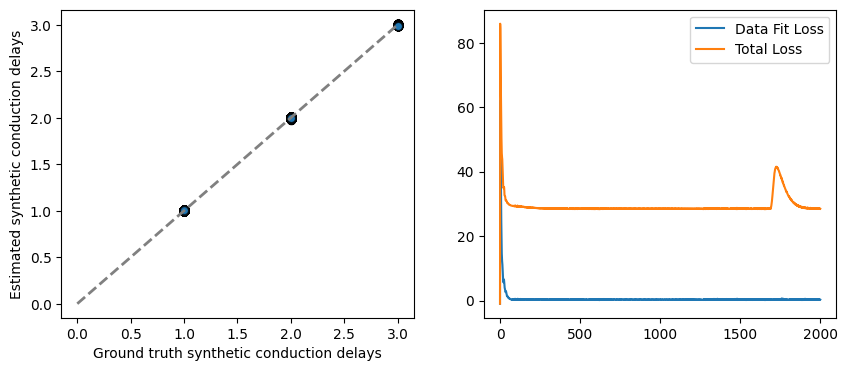

In [88]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
y_est_opt = solver.forward(design_model_masked, solver.torch.tensor(x_opt)).numpy()
ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7)
ax[0].plot(np.linspace(0,y_masked.max()), np.linspace(0,y_masked.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth synthetic conduction delays')
ax[0].set_ylabel('Estimated synthetic conduction delays')

ax[1].plot(df_loss, label='Data Fit Loss')
ax[1].plot(loss_logs, label='Total Loss')
ax[1].legend()

### Varying length of hidden entries

With delta optimization

In [109]:
np.random.seed(99)
percentages = np.linspace(0, 0.9, 6)

x_ground = remove_diagonal_entries(reduced_adj).flatten().astype(float)
deviations = []
deviations_masked = []
deltas = []

for pidx, p in tqdm(enumerate(percentages), total=len(percentages)):
    print(f"Running experiment with {p*100:.1f}% of missing observations")
    
    # Randomly remove p% of the observations
    y_non_complete = deepcopy(y_pred)
    n_remove = int(percentages[pidx] * len(y_pred))
    remove_indices = np.random.choice(len(y_pred), size=n_remove, replace=False)
    y_non_complete[remove_indices] = 0.0  # Set removed observations to zero

    y_ground = solver.torch.tensor(deepcopy(y_non_complete))

    x_init = solver.torch.tensor(np.random.rand(len(x_ground))).requires_grad_(True)

    non_zero_mask = y_ground > 0
    y_masked = y_ground[non_zero_mask]
    design_model_masked = design_model[non_zero_mask]

    delta_init = solver.torch.tensor(10.0).requires_grad_(True)

    x_opt, delta_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver_delta(x_init, y_masked, design_model_masked,
                                                n_iter=1000, verbose=False, 
                                                early_stop=1e-10, step_size=1, delta=delta_init,
                                                l2_penalty=0, return_logs=True)
    
    deviation_percent_masked = relative_error(x_ground[non_zero_mask], x_opt[non_zero_mask])
    deviation_percent = relative_error(x_ground[~non_zero_mask], x_opt[~non_zero_mask])
    
    deviations.append(deviation_percent)
    deviations_masked.append(deviation_percent_masked)
    deltas.append(delta_opt)

  0%|          | 0/6 [00:00<?, ?it/s]/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_7635/313203295.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_ground = solver.torch.tensor(deepcopy(y_non_complete))


Running experiment with 0.0% of missing observations


/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_7635/610408163.py:5: RuntimeWarning: Mean of empty slice.
  return distrib.mean(), distrib.std()
/Users/mikichan/miniconda3/envs/effective_delay/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/mikichan/miniconda3/envs/effective_delay/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/mikichan/miniconda3/envs/effective_delay/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/mikichan/miniconda3/envs/effective_delay/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 17%|█▋     

Running experiment with 18.0% of missing observations


 33%|███▎      | 2/6 [00:28<00:56, 14.21s/it]

...

 67%|██████▋   | 4/6 [00:48<00:21, 10.97s/it]

Running experiment with 72.0% of missing observations


 83%|████████▎ | 5/6 [00:53<00:08,  8.88s/it]

Running experiment with 90.0% of missing observations


100%|██████████| 6/6 [00:55<00:00,  9.28s/it]


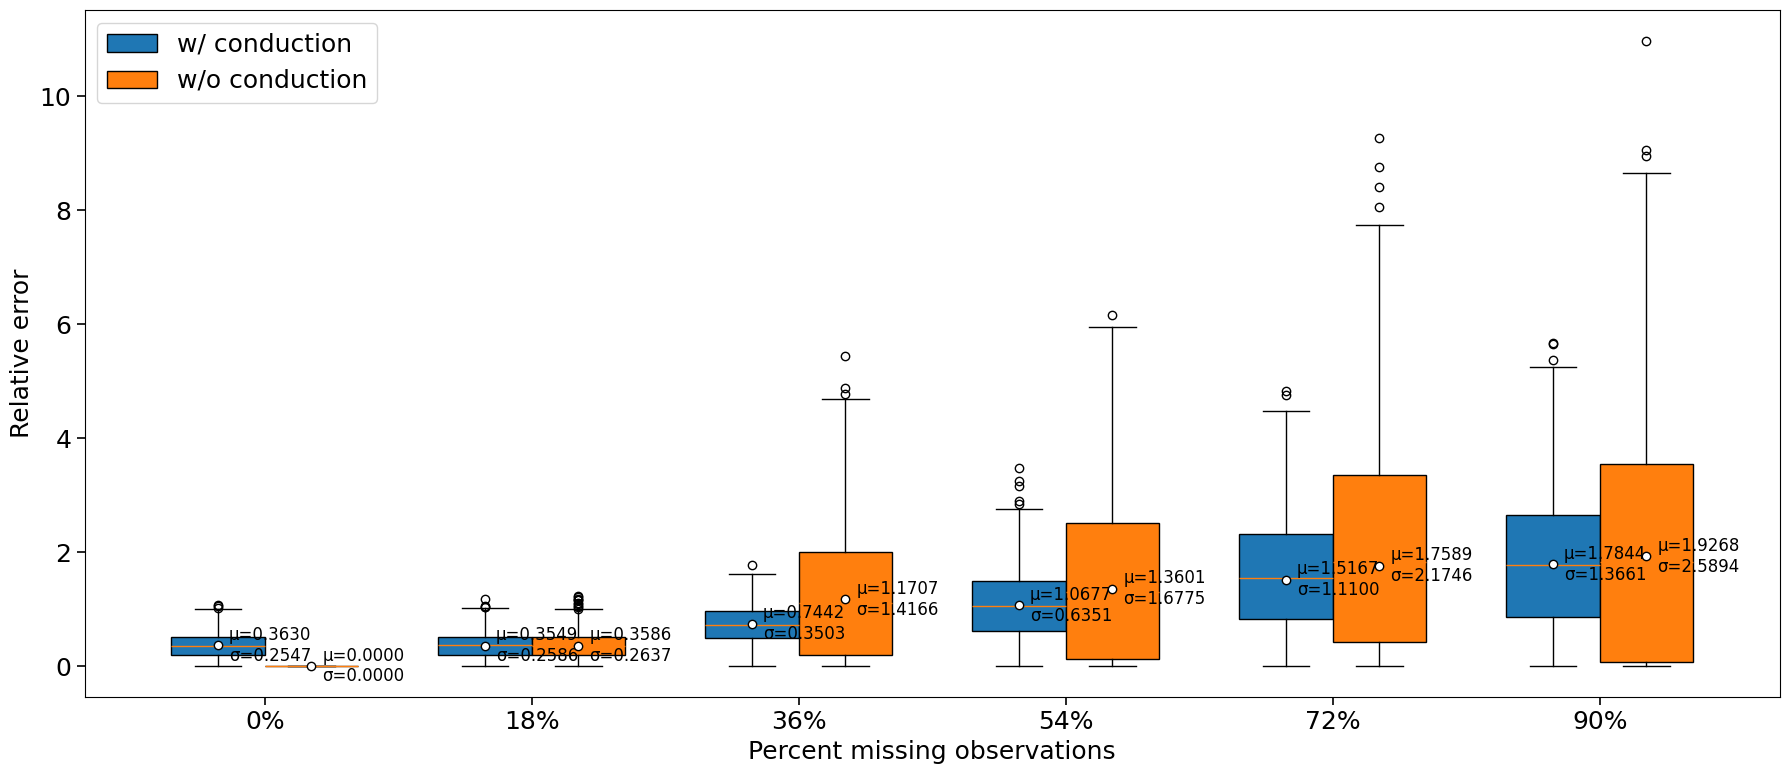

In [ ]:
# Adapted: create synthetic samples for lists of deviations and plot grouped boxplots
np.random.seed(0)

# extract means and stds from the lists, handle NaNs
means_masked = [float(m[0]) if not np.isnan(m[0]) else 0.0 for m in deviations_masked]
stds_masked  = [float(m[1]) if not np.isnan(m[1]) else 0.0 for m in deviations_masked]

means_unmasked = [float(m[0]) if not np.isnan(m[0]) else 0.0 for m in deviations]
stds_unmasked  = [float(m[1]) if not np.isnan(m[1]) else 0.0 for m in deviations]

# generate samples (ensure non-negative)
samples_masked = [np.clip(np.random.normal(loc=mu, scale=sigma if sigma>0 else 0.0, size=n_samples),
                          a_min=0, a_max=None)
                  for mu, sigma in zip(means_masked, stds_masked)]
samples_unmasked = [np.clip(np.random.normal(loc=mu, scale=sigma if sigma>0 else 0.0, size=n_samples),
                            a_min=0, a_max=None)
                    for mu, sigma in zip(means_unmasked, stds_unmasked)]

# prepare grouped boxplot positions
n_groups = len(samples_masked)
ind = np.arange(n_groups)
width = 0.35

fig, ax = plt.subplots(1, figsize=(18,8))

ax.cla()
bp1 = ax.boxplot([samples_masked[i] for i in range(n_groups)],
                 positions=ind - width/2, widths=width, patch_artist=True, boxprops=dict(facecolor='C0'))
bp2 = ax.boxplot([samples_unmasked[i] for i in range(n_groups)],
                    positions=ind + width/2, widths=width, patch_artist=True, boxprops=dict(facecolor='C1'))

# plot means and annotate
for i, (m_s, m_u, s_s, s_u) in enumerate(zip(means_masked, means_unmasked, stds_masked, stds_unmasked)):
    ax.scatter(i - width/2, m_s, color='white', edgecolor='k', zorder=3)
    ax.text(i - width/2 + 0.04, m_s, f"μ={m_s:.4f}\nσ={s_s:.4f}", va='center', fontsize=8)
    ax.scatter(i + width/2, m_u, color='white', edgecolor='k', zorder=3)
    ax.text(i + width/2 + 0.04, m_u, f"μ={m_u:.4f}\nσ={s_u:.4f}", va='center', fontsize=8)

# x labels using percentages
ax.set_xticks(ind)
ax.set_xticklabels([f"{int(p*100)}%" for p in percentages])
ax.set_xlabel('Percent missing observations')
ax.set_ylabel('Relative error')

# enlarge fonts and tick sizes for the figure and boxplots
fontsize = 18
tick_labelsize = 18
text_fontsize = 12

# Apply to all axes in the current figure
for a in fig.axes:
    # axis labels and title
    if a.title:
        a.title.set_fontsize(fontsize + 2)
    a.xaxis.label.set_fontsize(fontsize)
    a.yaxis.label.set_fontsize(fontsize)
    # ticks
    a.tick_params(axis='both', which='major', labelsize=tick_labelsize, width=1.2, length=6)
    a.tick_params(axis='both', which='minor', labelsize=tick_labelsize-2, width=1.0, length=4)
    # any manual text annotations
    for t in a.texts:
        t.set_fontsize(text_fontsize)
    # legend (if present)
    leg = a.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(text_fontsize)
        if leg.get_title():
            leg.get_title().set_fontsize(text_fontsize)

# Ensure xtick labels use the desired fontsize
ax.set_xticks(ind)
ax.set_xticklabels([f"{int(p*100)}%" for p in percentages], fontsize=fontsize)

ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['w/ conduction', 'w/o conduction'], loc='upper left', prop={'size': 18})

# increase overall figure title / layout if any
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.draw()
plt.show()

Without hyperparamter optimization

In [113]:
np.random.seed(99)
percentages = np.linspace(0, 0.9, 6)

x_ground = remove_diagonal_entries(reduced_adj).flatten().astype(float)
deviations = []
deviations_masked = []

for pidx, p in tqdm(enumerate(percentages), total=len(percentages)):
    print(f"Running experiment with {p*100:.1f}% of missing observations")
    
    # Randomly remove p% of the observations
    y_non_complete = deepcopy(y_pred)
    n_remove = int(percentages[pidx] * len(y_pred))
    remove_indices = np.random.choice(len(y_pred), size=n_remove, replace=False)
    y_non_complete[remove_indices] = 0.0  # Set removed observations to zero

    y_ground = solver.torch.tensor(deepcopy(y_non_complete))

    x_init = solver.torch.tensor(np.random.rand(len(x_ground))).requires_grad_(True)

    non_zero_mask = y_ground > 0
    y_masked = y_ground[non_zero_mask]
    design_model_masked = design_model[non_zero_mask]

    x_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver(x_init, y_masked, design_model_masked,
                                            n_iter=2000, verbose=False, 
                                            early_stop=1e-10, step_size=5e-2,
                                            l2_penalty=5e-1, return_logs=True)
    
    deviation_percent_masked = relative_error(x_ground[non_zero_mask], x_opt[non_zero_mask])
    deviation_percent = relative_error(x_ground[~non_zero_mask], x_opt[~non_zero_mask])
    
    deviations.append(deviation_percent)
    deviations_masked.append(deviation_percent_masked)

  0%|          | 0/6 [00:00<?, ?it/s]/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_7635/898089726.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_ground = solver.torch.tensor(deepcopy(y_non_complete))


Running experiment with 0.0% of missing observations


/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_7635/610408163.py:5: RuntimeWarning: Mean of empty slice.
  return distrib.mean(), distrib.std()
/Users/mikichan/miniconda3/envs/effective_delay/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/mikichan/miniconda3/envs/effective_delay/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/mikichan/miniconda3/envs/effective_delay/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/mikichan/miniconda3/envs/effective_delay/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 17%|█▋     

Running experiment with 18.0% of missing observations


 33%|███▎      | 2/6 [00:58<01:54, 28.69s/it]

...

 67%|██████▋   | 4/6 [01:34<00:42, 21.29s/it]

Running experiment with 72.0% of missing observations


 83%|████████▎ | 5/6 [01:45<00:17, 17.48s/it]

Running experiment with 90.0% of missing observations


100%|██████████| 6/6 [01:49<00:00, 18.31s/it]


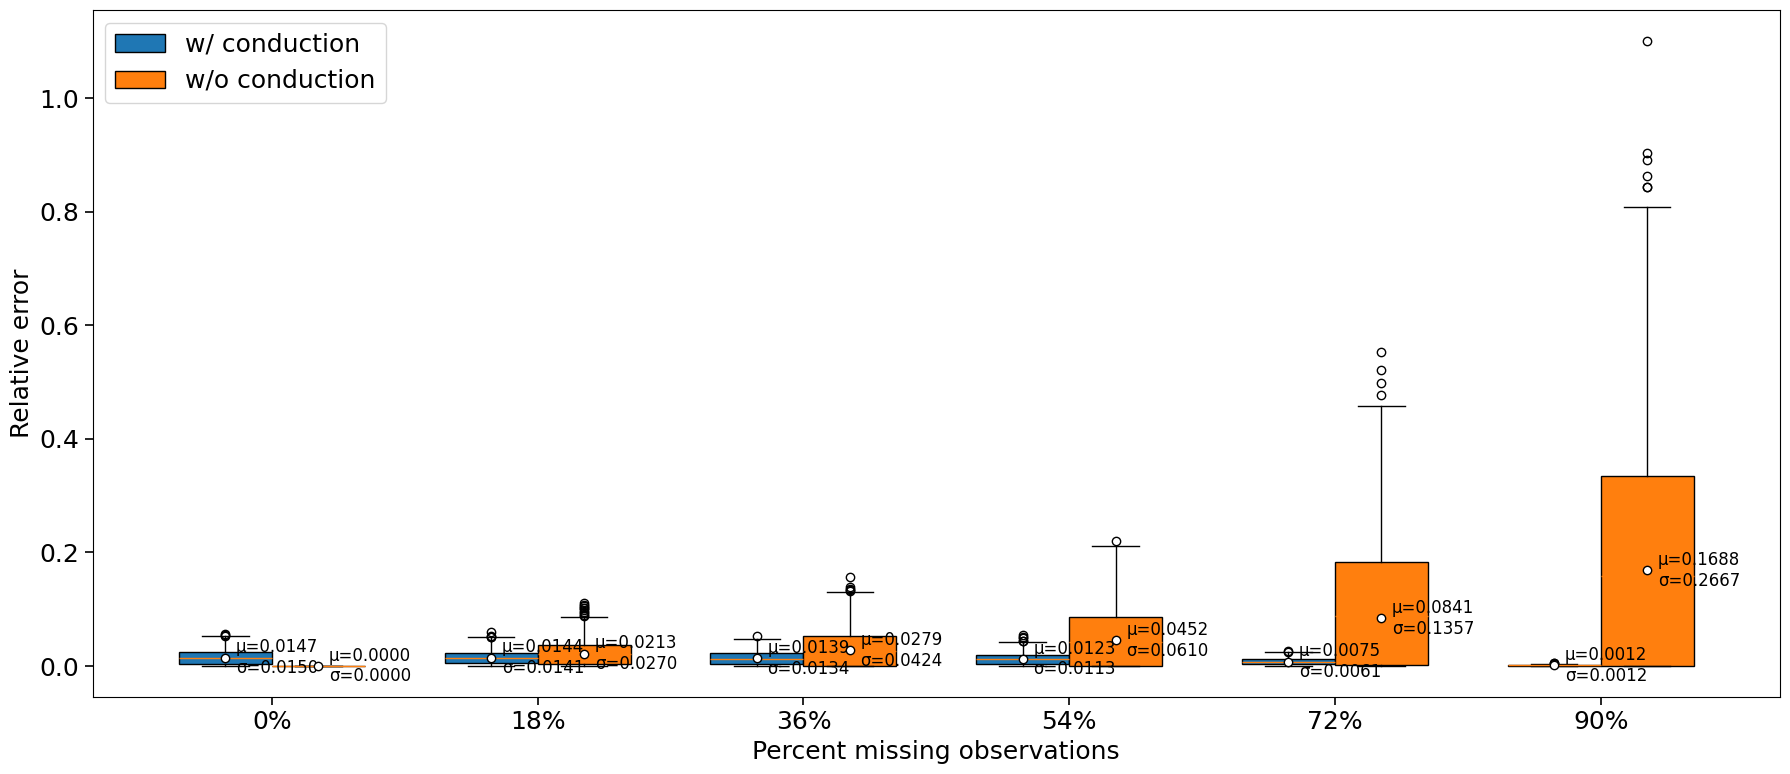

In [114]:
# Adapted: create synthetic samples for lists of deviations and plot grouped boxplots
np.random.seed(0)

# extract means and stds from the lists, handle NaNs
means_masked = [float(m[0]) if not np.isnan(m[0]) else 0.0 for m in deviations_masked]
stds_masked  = [float(m[1]) if not np.isnan(m[1]) else 0.0 for m in deviations_masked]

means_unmasked = [float(m[0]) if not np.isnan(m[0]) else 0.0 for m in deviations]
stds_unmasked  = [float(m[1]) if not np.isnan(m[1]) else 0.0 for m in deviations]

# generate samples (ensure non-negative)
samples_masked = [np.clip(np.random.normal(loc=mu, scale=sigma if sigma>0 else 0.0, size=n_samples),
                          a_min=0, a_max=None)
                  for mu, sigma in zip(means_masked, stds_masked)]
samples_unmasked = [np.clip(np.random.normal(loc=mu, scale=sigma if sigma>0 else 0.0, size=n_samples),
                            a_min=0, a_max=None)
                    for mu, sigma in zip(means_unmasked, stds_unmasked)]

# prepare grouped boxplot positions
n_groups = len(samples_masked)
ind = np.arange(n_groups)
width = 0.35

fig, ax = plt.subplots(1, figsize=(18,8))

ax.cla()
bp1 = ax.boxplot([samples_masked[i] for i in range(n_groups)],
                 positions=ind - width/2, widths=width, patch_artist=True, boxprops=dict(facecolor='C0'))
bp2 = ax.boxplot([samples_unmasked[i] for i in range(n_groups)],
                    positions=ind + width/2, widths=width, patch_artist=True, boxprops=dict(facecolor='C1'))

# plot means and annotate
for i, (m_s, m_u, s_s, s_u) in enumerate(zip(means_masked, means_unmasked, stds_masked, stds_unmasked)):
    ax.scatter(i - width/2, m_s, color='white', edgecolor='k', zorder=3)
    ax.text(i - width/2 + 0.04, m_s, f"μ={m_s:.4f}\nσ={s_s:.4f}", va='center', fontsize=8)
    ax.scatter(i + width/2, m_u, color='white', edgecolor='k', zorder=3)
    ax.text(i + width/2 + 0.04, m_u, f"μ={m_u:.4f}\nσ={s_u:.4f}", va='center', fontsize=8)

# x labels using percentages
ax.set_xticks(ind)
ax.set_xticklabels([f"{int(p*100)}%" for p in percentages])
ax.set_xlabel('Percent missing observations')
ax.set_ylabel('Relative error')

# enlarge fonts and tick sizes for the figure and boxplots
fontsize = 18
tick_labelsize = 18
text_fontsize = 12

# Apply to all axes in the current figure
for a in fig.axes:
    # axis labels and title
    if a.title:
        a.title.set_fontsize(fontsize + 2)
    a.xaxis.label.set_fontsize(fontsize)
    a.yaxis.label.set_fontsize(fontsize)
    # ticks
    a.tick_params(axis='both', which='major', labelsize=tick_labelsize, width=1.2, length=6)
    a.tick_params(axis='both', which='minor', labelsize=tick_labelsize-2, width=1.0, length=4)
    # any manual text annotations
    for t in a.texts:
        t.set_fontsize(text_fontsize)
    # legend (if present)
    leg = a.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(text_fontsize)
        if leg.get_title():
            leg.get_title().set_fontsize(text_fontsize)

# Ensure xtick labels use the desired fontsize
ax.set_xticks(ind)
ax.set_xticklabels([f"{int(p*100)}%" for p in percentages], fontsize=fontsize)

ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['w/ conduction', 'w/o conduction'], loc='upper left', prop={'size': 18})

# increase overall figure title / layout if any
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.draw()
plt.show()

## Hyperparameter choice considering cross validation of masked delays

In [ ]:
# conductance delay to regress
with open(op.join(path_to_ftract, 'peak_delay__median.txt')) as f:
    text = f.readlines()

y_ground_mat = []
for t in text[8:]:
    y_ground_mat.append(t.split(' '))
y_ground_mat = np.array(y_ground_mat).astype(float)
y_ground_mat = np.nan_to_num(y_ground_mat[:-1, :-1])

prob_thresh = 0
y_ground_mat *= ftract_prob > prob_thresh
y_ground = solver.torch.tensor(remove_diagonal_entries(y_ground_mat).flatten())

#### Modelling including $\delta$

In [44]:
a = 0.8
design_shortest = regmod.apply_alpha_to_design(design_matrix=design_matrices, n_subopt=max_path_depth, alpha=a)

non_zero_mask = y_ground > 0
y_masked = y_ground[non_zero_mask]
design_model_masked = design_shortest[non_zero_mask]
design_model_masked = solver.torch.from_numpy(design_model_masked)

In [54]:
np.random.seed(99)
x_init = solver.torch.from_numpy(np.random.rand(len(y_ground))).requires_grad_(True)
delta_init = solver.torch.tensor(10.0).requires_grad_(True)

x_opt, delta_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver_delta(x_init, y_masked, design_model_masked,
                                            n_iter=1000, verbose=False, 
                                            early_stop=1e-10, step_size=1, delta=delta_init,
                                            l2_penalty=0, return_logs=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

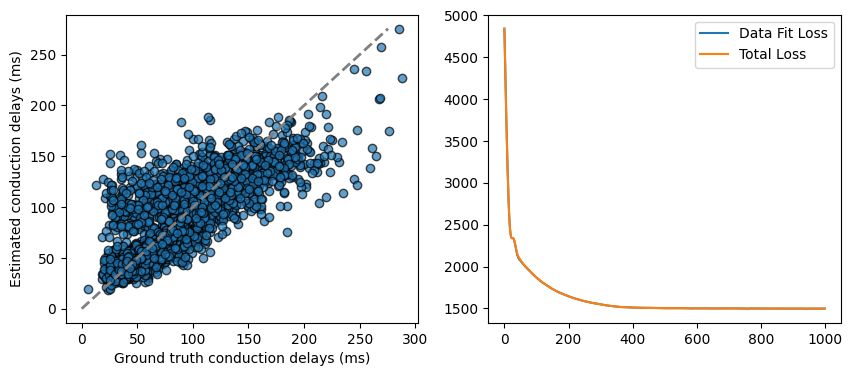

In [55]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
y_est_opt = solver.forward(design_model_masked, x_opt + delta_opt * (x_opt > 0)).numpy()

ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7)
ax[0].plot(np.linspace(0,y_est_opt.max()), np.linspace(0,y_est_opt.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth conduction delays (ms)')
ax[0].set_ylabel('Estimated conduction delays (ms)')

ax[1].plot(df_loss[1:], label='Data Fit Loss')
ax[1].plot(loss_logs[1:], label='Total Loss')
ax[1].legend()

(<Figure size 1000x500 with 4 Axes>,
 <Axes: title={'center': 'Effective delays $x$ (loss=0.4409 ms/edge)'}>)

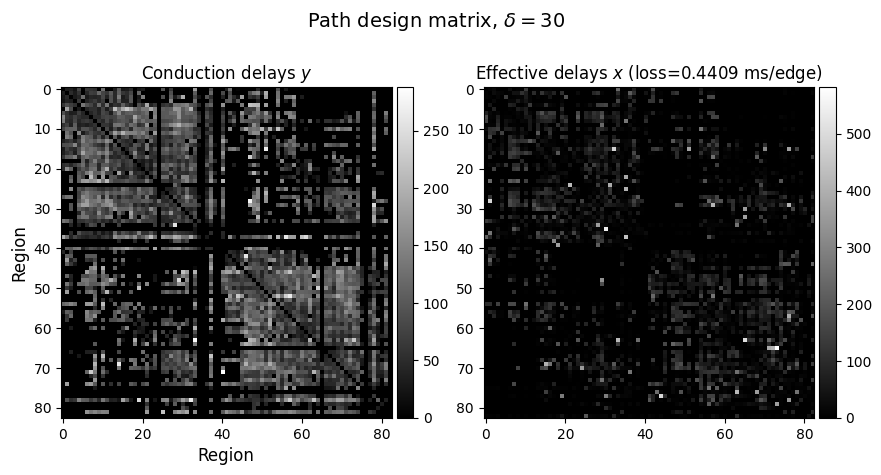

In [56]:
x_pred_mat = add_diagonal_entries(x_opt.reshape(adj.shape[0], adj.shape[1]-1))

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
fig.suptitle(rf"Path design matrix, $\delta={30}$", fontsize=14)

axes[0].imshow(y_ground_mat, cmap='gray')
axes[0].set_title(f"Conduction delays $y$", fontsize=12)
axes[0].set_xlabel("Region", fontsize=12)
axes[0].set_ylabel("Region", fontsize=12)
add_cbar(fig, axes[0])
# utils.annotate_heatmap(fig, axes, np.round(x_pred_mat,4), adapt_color=0.6)

prop_loss = loss / np.sum(y_ground_mat != 0)
axes[1].imshow(x_pred_mat, cmap='gray')
axes[1].set_title(f"Effective delays $x$ (loss={np.round(prop_loss,4)} ms/edge)", fontsize=12)
add_cbar(fig, axes[1])

#axes[2].imshow(x_pred_mat, cmap='gray', vmin=0)
#axes[2].set_title(f"Clipped $\hat y$")
#utils.add_cbar(fig, axes[2])

# if save_plots:
#     fig.savefig(f"../figures/estimated_delays_a{a}.png", dpi=300)

Modelling with optimized delta

In [ ]:
a = 0.8
design_shortest = regmod.apply_alpha_to_design(design_matrix=design_matrices, n_subopt=max_path_depth, alpha=a)

non_zero_mask = y_ground > 0
y_masked = y_ground[non_zero_mask]
design_model_masked = design_shortest[non_zero_mask]
design_model_masked = solver.torch.from_numpy(design_model_masked)

3005 -> 3160


In [ ]:
np.random.seed(99)
x_init = solver.torch.tensor(np.random.rand(len(y_ground))).requires_grad_(True)
delta_init = solver.torch.tensor(10.0).requires_grad_(True)

x = deepcopy(x_init)
delta = deepcopy(delta_init)
x_opt, delta_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver_delta(x, y_masked, design_model_masked,
                                            n_iter=2000, verbose=False, 
                                            early_stop=1e-10, step_size=1, delta=delta,
                                            l2_penalty=0, return_logs=True)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

(1470.0, 1550.0)

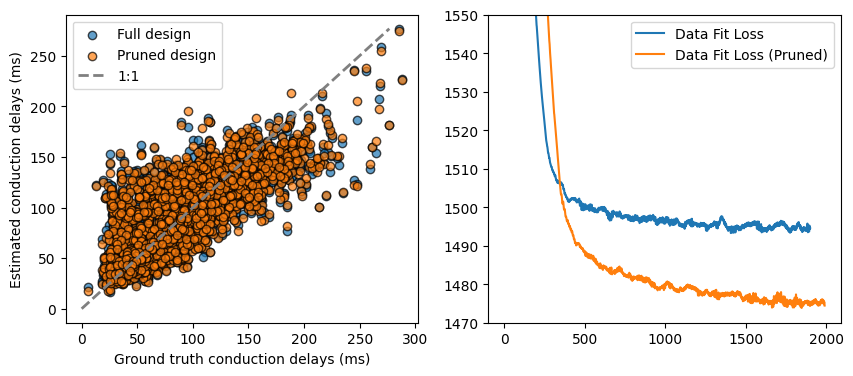

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

y_est_opt = solver.forward(design_model_masked, x_opt + delta_opt * (x_opt > 0)).numpy()

ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7, label='Full design')

ax[0].plot(np.linspace(0,y_est_opt.max()), np.linspace(0,y_est_opt.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth conduction delays (ms)')
ax[0].set_ylabel('Estimated conduction delays (ms)')

ax[1].plot(df_loss[100:], label='Data Fit Loss')
ax[0].legend()
ax[1].legend()
ax[1].set_ylim(1470, 1550)

In [8]:
non_zero_mask = y_ground > 0
y_masked = y_ground[non_zero_mask]

In [ ]:
np.random.seed(99)
x_init = solver.torch.tensor(np.random.rand(len(y_ground)), dtype=solver.torch.float32).requires_grad_(True)
alpha_init = solver.torch.tensor(0.0, dtype=solver.torch.float32).requires_grad_(True)
delta_init = solver.torch.tensor(10.0, dtype=solver.torch.float32).requires_grad_(True)

n_iter = 1000
x = deepcopy(x_init)
alpha = deepcopy(alpha_init)
delta = deepcopy(delta_init)
x_opt, (alpha_opt, delta_opt), loss, loss_logs, df_loss = solver.effective_delay_solver(x, y_masked, design=solver.torch.tensor(design_matrices), nzmask=non_zero_mask, alpha=alpha,
                                            n_iter=n_iter, verbose=False, 
                                            early_stop=1e-10, step_size=5e-1, delta=delta,
                                            l2_penalty=0, return_logs=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
alpha_opt, delta_opt

(0.5372152924537659, 4.719155788421631, 0.4900342524051666, 4.110581398010254)

In [ ]:
design_model_masked = solver.apply_alpha_to_design_torch(solver.torch.tensor(design_matrices), alpha_opt)
design_model_masked = design_model_masked[non_zero_mask]

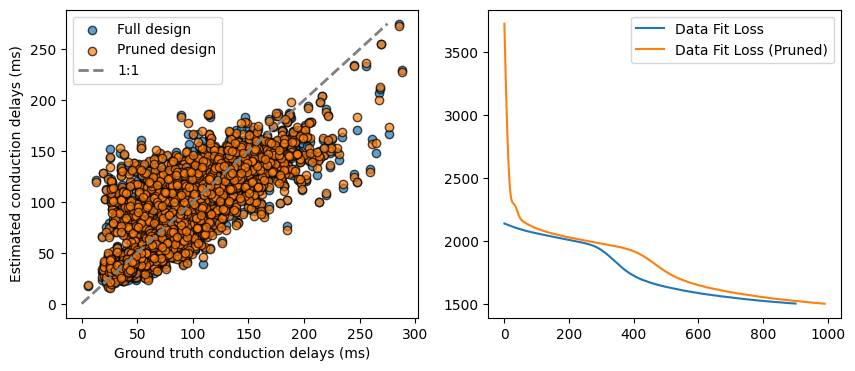

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

y_est_opt = solver.forward(design_model_masked, x_opt + delta_opt * (x_opt > 0)).numpy()

ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7, label='Full design')

ax[0].plot(np.linspace(0,y_est_opt.max()), np.linspace(0,y_est_opt.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth conduction delays (ms)')
ax[0].set_ylabel('Estimated conduction delays (ms)')

ax[1].plot(df_loss[100:], label='Data Fit Loss')
# ax[1].plot(loss_logs[1:], label='Total Loss')
# ax[1].plot(loss_logs_pruned[1:], label='Total Loss (Pruned)')
# ax[1].set_yscale('log')
ax[0].legend()
ax[1].legend()